<a href="https://colab.research.google.com/github/afrin-taj/AI-Tool-Usage-Productivity-Analysis/blob/main/AI_Tool_Usage_Productivity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv("AI Tools Productivity.csv")

In [15]:
df.head()

,Employee_ID,Age,Industry,Job_Role,Experience_Years,Company_Size,Remote_Work_Type,AI_Tools_Used,Daily_AI_Usage_Hours,Primary_AI_Tool,...,Time_Saved_Per_Day_Minutes,Learning_Time_Per_Week_Hours,Meetings_Per_Day,Work_Hours_Per_Day,Job_Satisfaction,Productivity_Change,Salary_USD,Promotion_Last_Year,Fear_of_AI_Replacing_Job,Target
0,1,50,Tech,Consultant,14,Large,Onsite,2,3.9,Midjourney,...,102,2.7,6,4.3,High,Decreased,73423,No,Low,Low
1,2,45,Finance,Data Scientist,2,Large,Remote,4,4.8,Grok,...,37,0.0,3,5.1,Low,Same,60769,No,Low,Low
2,3,43,Marketing,Consultant,11,Small,Onsite,0,1.5,Midjourney,...,169,0.3,3,6.2,High,Increased,47189,No,Medium,Low
3,4,24,Retail,Software Developer,0,Medium,Remote,2,3.4,Gemini,...,166,0.1,0,9.8,Low,Same,39433,Yes,Low,High
4,5,30,Education,Consultant,4,Large,Onsite,1,3.4,Copilot,...,171,3.0,6,5.0,High,Decreased,39152,No,High,High


In [16]:
df.shape

(30000, 21)

In [17]:
df.columns

Index(['Employee_ID', 'Age', 'Industry', 'Job_Role', 'Experience_Years',
       'Company_Size', 'Remote_Work_Type', 'AI_Tools_Used',
       'Daily_AI_Usage_Hours', 'Primary_AI_Tool', 'Tasks_Automated_Percent',
       'Time_Saved_Per_Day_Minutes', 'Learning_Time_Per_Week_Hours',
       'Meetings_Per_Day', 'Work_Hours_Per_Day', 'Job_Satisfaction',
       'Productivity_Change', 'Salary_USD', 'Promotion_Last_Year',
       'Fear_of_AI_Replacing_Job', 'Target'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Employee_ID                   30000 non-null  int64  
 1   Age                           30000 non-null  int64  
 2   Industry                      30000 non-null  object 
 3   Job_Role                      30000 non-null  object 
 4   Experience_Years              30000 non-null  int64  
 5   Company_Size                  30000 non-null  object 
 6   Remote_Work_Type              30000 non-null  object 
 7   AI_Tools_Used                 30000 non-null  int64  
 8   Daily_AI_Usage_Hours          30000 non-null  float64
 9   Primary_AI_Tool               30000 non-null  object 
 10  Tasks_Automated_Percent       30000 non-null  int64  
 11  Time_Saved_Per_Day_Minutes    30000 non-null  int64  
 12  Learning_Time_Per_Week_Hours  30000 non-null  float64
 13  M

In [19]:
df.describe()

,Employee_ID,Age,Experience_Years,AI_Tools_Used,Daily_AI_Usage_Hours,Tasks_Automated_Percent,Time_Saved_Per_Day_Minutes,Learning_Time_Per_Week_Hours,Meetings_Per_Day,Work_Hours_Per_Day,Salary_USD
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.00000,30000.000000
mean,15000.500000,38.019533,8.039200,1.998200,2.500913,39.305200,89.705567,2.993697,3.507167,6.99968,57113.294467
std,8660.398374,9.537483,7.407471,1.409443,1.441359,23.060026,52.173100,1.737679,2.297402,1.73196,16461.253737
min,1.000000,22.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.00000,25022.000000
25%,7500.750000,30.000000,2.000000,1.000000,1.300000,19.000000,44.000000,1.500000,1.000000,5.50000,44938.000000
50%,15000.500000,38.000000,6.000000,2.000000,2.500000,39.000000,90.000000,3.000000,4.000000,7.00000,54149.500000
75%,22500.250000,46.000000,13.000000,3.000000,3.700000,59.000000,135.000000,4.500000,6.000000,8.50000,66934.500000
max,30000.000000,54.000000,32.000000,4.000000,5.000000,79.000000,179.000000,6.000000,7.000000,10.00000,120549.000000


In [20]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Industry,0
Job_Role,0
Experience_Years,0
Company_Size,0
Remote_Work_Type,0
AI_Tools_Used,0
Daily_AI_Usage_Hours,0
Primary_AI_Tool,0


In [23]:
df['Productivity_Change'].value_counts()

,count
Productivity_Change,
Increased,10086
Same,9992
Decreased,9922


In [24]:
df['Primary_AI_Tool'].value_counts()

,count
Primary_AI_Tool,
Midjourney,5099
Claude,5067
Grok,5037
Copilot,4941
ChatGPT,4929
Gemini,4927


In [25]:
df['Daily_AI_Usage_Hours'].mean()

np.float64(2.5009133333333335)

In [27]:
productivity_mapping = {'Increased': 1, 'Same': 0, 'Decreased': -1}
df['Productivity_Change_Numeric'] = df['Productivity_Change'].map(productivity_mapping)

df.groupby('Industry')['Productivity_Change_Numeric'].mean().sort_values(ascending=False)

,Productivity_Change_Numeric
Industry,
Retail,0.026390
Healthcare,0.021069
Education,0.010685
Tech,-0.006220
Marketing,-0.008597
Finance,-0.010675


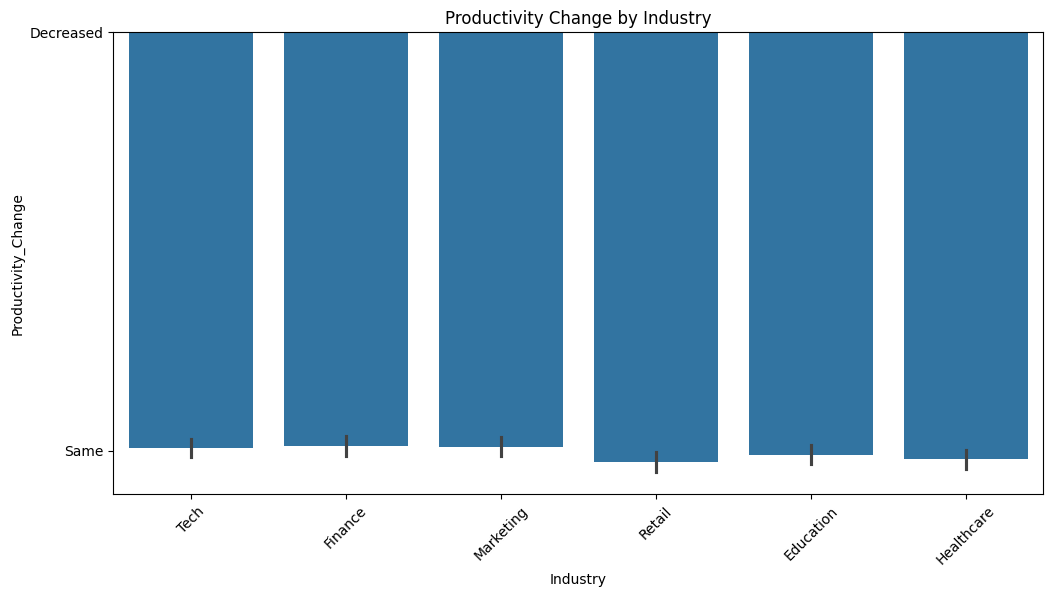

In [28]:
plt.figure(figsize=(12,6))
sns.barplot(x='Industry', y='Productivity_Change', data=df)

plt.xticks(rotation=45)
plt.title("Productivity Change by Industry")
plt.show()

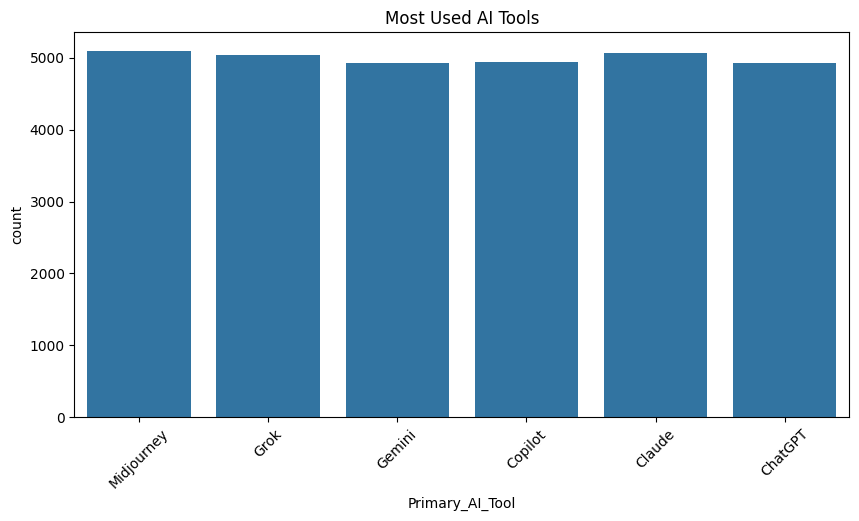

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(x='Primary_AI_Tool', data=df)

plt.xticks(rotation=45)
plt.title("Most Used AI Tools")
plt.show()

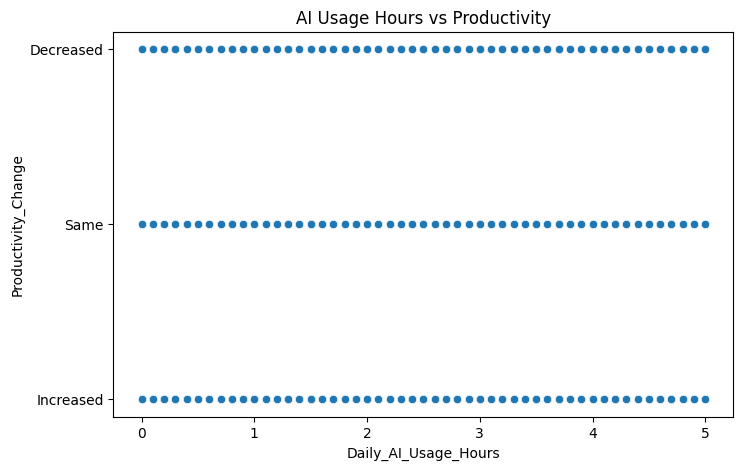

In [30]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Daily_AI_Usage_Hours',
    y='Productivity_Change',
    data=df
)

plt.title("AI Usage Hours vs Productivity")
plt.show()

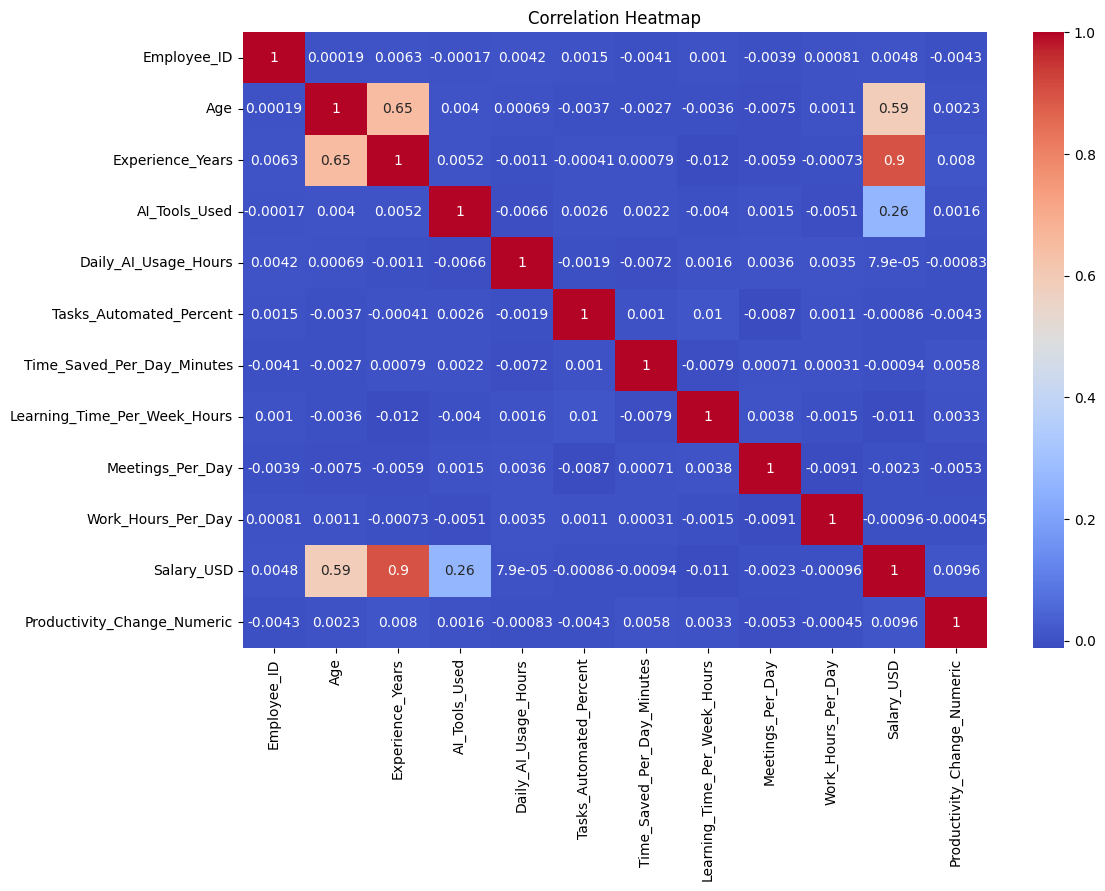

In [31]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

Analyze

In [32]:
df['Task_Time_Before_AI'] = (
    df['Time_Saved_Per_Day_Minutes']
    + np.random.randint(60, 180, size=len(df))
)

df['Task_Time_After_AI'] = (
    df['Task_Time_Before_AI']
    - df['Time_Saved_Per_Day_Minutes']
)

In [33]:
df['Errors_Before_AI'] = np.random.randint(10, 50, size=len(df))

df['Errors_After_AI'] = (
    df['Errors_Before_AI']
    - np.random.randint(1, 10, size=len(df))
)

In [34]:
df['Productivity_Gain_Percent'] = (
    (
        df['Task_Time_Before_AI']
        - df['Task_Time_After_AI']
    )
    /
    df['Task_Time_Before_AI']
) * 100

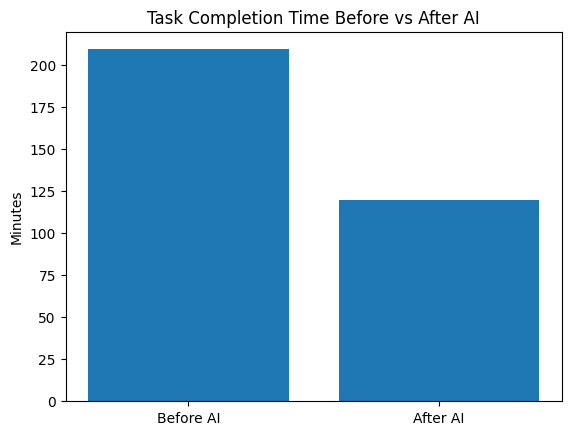

In [35]:
before = df['Task_Time_Before_AI'].mean()
after = df['Task_Time_After_AI'].mean()

plt.bar(
    ['Before AI', 'After AI'],
    [before, after]
)

plt.title("Task Completion Time Before vs After AI")
plt.ylabel("Minutes")
plt.show()

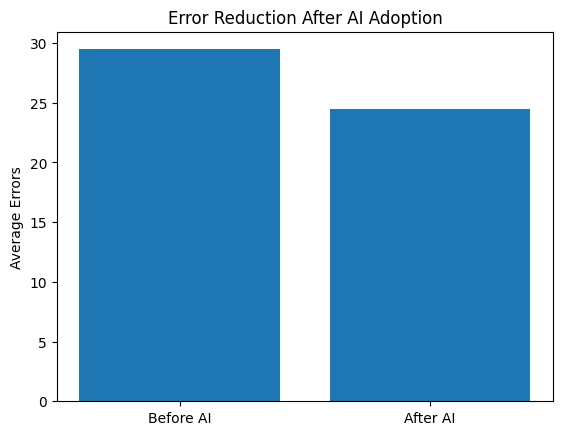

In [36]:
before_errors = df['Errors_Before_AI'].mean()
after_errors = df['Errors_After_AI'].mean()

plt.bar(
    ['Before AI', 'After AI'],
    [before_errors, after_errors]
)

plt.title("Error Reduction After AI Adoption")
plt.ylabel("Average Errors")
plt.show()

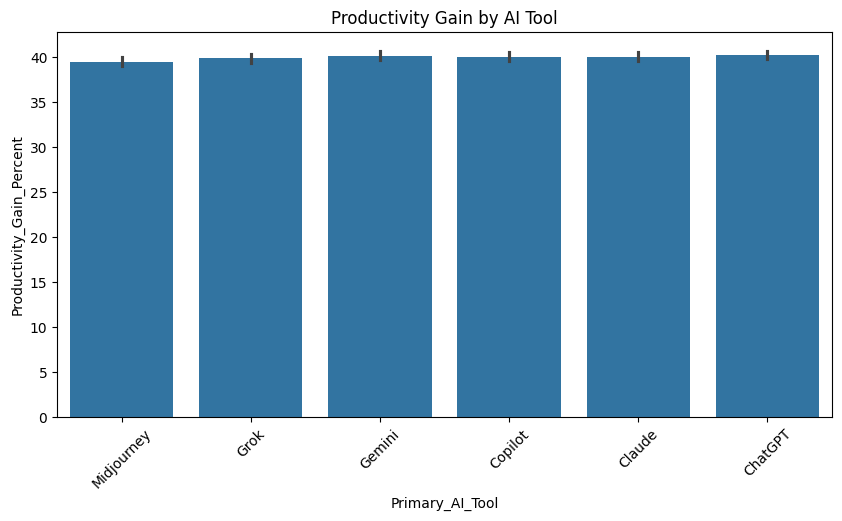

In [37]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Primary_AI_Tool',
    y='Productivity_Gain_Percent',
    data=df
)

plt.xticks(rotation=45)
plt.title("Productivity Gain by AI Tool")

plt.show()

ROI (Return on investment)

In [38]:
df['ROI'] = (
    df['Time_Saved_Per_Day_Minutes']
    * 30
) / 100

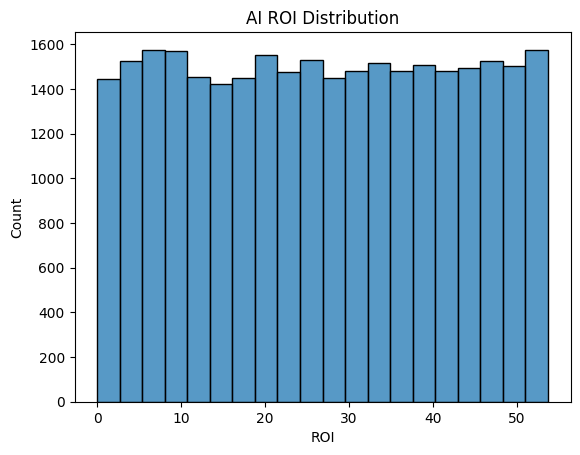

In [39]:
sns.histplot(df['ROI'], bins=20)

plt.title("AI ROI Distribution")

plt.show()

In [41]:
df['Error_Reduction'] = (
    df['Errors_Before_AI']
    - df['Errors_After_AI']
)

In [42]:
df.to_csv("final_ai_productivity.csv", index=False)